##  Numpy & Pandas training

### Synthetic dataset
#### (numpy)

In [1]:
import numpy as np
import pandas as pd

# ============================================================
# ГЕНЕРАЦИЯ СИНТЕТИЧЕСКОГО ДАТАСЕТА
# ============================================================

np.random.seed(42)

n = 200  # количество записей

# Признаки
area = np.random.randint(30, 150, n)              # площадь дома (м²)
rooms = np.random.randint(1, 6, n)               # количество комнат
floor = np.random.randint(1, 10, n)              # этаж
age = np.random.randint(0, 50, n)                # возраст дома (лет)
distance_to_center = np.random.uniform(0.5, 15, n) # км до центра

# Целевая переменная: цена квартиры (в тыс. у.е.)
price = (2.5 * area 
         + 10 * rooms 
         - 0.3 * age 
         - 2.0 * distance_to_center 
         + np.random.normal(0, 15, n))  # шум

price = np.round(price, 0).astype(int)

# Собираем датафрейм
df = pd.DataFrame({
    'area': area,
    'rooms': rooms,
    'floor': floor,
    'age': age,
    'distance_to_center': distance_to_center,
    'price': price
})

# Показываем первые строки

#print("\nРазмер датасета:", df.shape)
#print(df.head())
# Превращаем в Numpy-массив для тренировок
data = df.values  # или df[['area', 'rooms', 'floor', 'age', 'distance_to_center', 'price']].values

print("Первые 5 строк (Numpy array):")
print(data[:5])
print(f"\nРазмер данных: {data.shape}")

Первые 5 строк (Numpy array):
[[132.           5.           8.          38.          13.17760527
  352.        ]
 [ 81.           3.           7.           0.           7.9709228
  240.        ]
 [122.           3.           9.           2.          14.61010006
  323.        ]
 [ 44.           4.           4.          12.           9.22806324
  138.        ]
 [136.           2.           4.          27.           3.74581146
  335.        ]]

Размер данных: (200, 6)


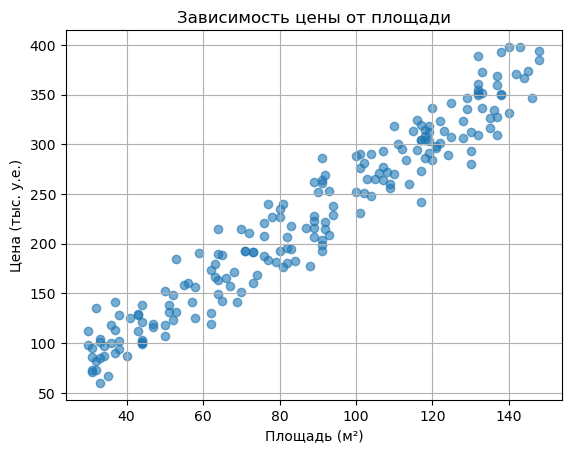

In [2]:
import matplotlib.pyplot as plt

plt.scatter(area, price, alpha=0.6)
plt.xlabel('Площадь (м²)')
plt.ylabel('Цена (тыс. у.е.)')
plt.title('Зависимость цены от площади')
plt.grid()
plt.show()

In [3]:
# Задача 1. Найди среднюю цену квартиры.
print(f"{data[:,-1].mean()} - average price")

226.24 - average price


In [4]:
# Задача 2. Найди максимальную и минимальную площадь (area).
haracters = (float(data[:,0].max()) ,float(data[:,0].min()) )
print(haracters)

(148.0, 30.0)


In [5]:
# Задача 3. Найди индекс квартиры с самой высокой ценой.
print(f"{data[:,-1].argmax()} - индекс квартиры с максимальной ценой")

65 - индекс квартиры с максимальной ценой


In [6]:
# Задача 4. Найди дисперсию возраста (age) домов.
print(f"{data[:,3].var()} - дисперсия возраста домов")

210.65277500000005 - дисперсия возраста домов


In [7]:
# Задача 5. Нормализуй цену (price) по min/max шкале в диапазон [0, 1]
price  = (data[:, -1] - data[:,-1].min())/(data[:,-1].max() - data[:,-1].min())
price[:5]

array([0.86390533, 0.53254438, 0.77810651, 0.23076923, 0.81360947])

In [8]:
# Задача 6. Выбери все квартиры, где цена больше средней цены.
mask = data[:,-1] > data[:,-1].mean()
vibor = data[mask]
print(len(vibor))

100


In [9]:
# Задача 7. Выбери квартиры, где количество комнат > 3 И возраст < 10 лет.
maska = (data[:,1] > 3) & (data[:,3] < 10)
kolvo = data[maska]
print(len(kolvo))

14


In [10]:
# Задача 8. Найди долю квартир, у которых площадь > 100 м² И цена > 200 тыс.
kvartiri = np.array([row for row in data if ((row[-1] > 200) & (row[0] > 100))])
print(len(kvartiri))

83


In [11]:
# Задача 9. Добавь столбец "price_per_m2" (цена за квадратный метр) как Numpy-массив.
price_per_m2 = data[:, -1] / data[:, 0]
print(data.shape)
data = np.column_stack((data, price_per_m2))
print(data.shape)
print(data[0])

(200, 6)
(200, 7)
[132.           5.           8.          38.          13.17760527
 352.           2.66666667]


In [12]:
# Задача 10. Найди индексы 5 самых дорогих квартир.
prices_all = data[:,-1]
prices_5 = np.argpartition(prices_all, -5)[-5:]
print(prices_5)
for kv in prices_5:
    print(prices_all[kv])

[127  76 115 170  53]
3.3684210526315788
3.810810810810811
3.490566037735849
3.7333333333333334
4.21875


In [13]:
# Задача 11. Найди индексы квартир, у которых цена больше 200 тыс. (используй np.where)
indeksi = np.where(data[:,-2] > 200)
print(indeksi[0])

# Дополнительно сделал словарь дабы потренероваться
option = {
    'наоборот' : indeksi[0][::-1],
    'первые 5' : indeksi[0][:5],
    'только четные' : indeksi[0][::2],
    'по идее default кроме последнего' : indeksi[0][:-1:],
    'default' : indeksi[0]
}
for key, value in (option.items()):
    print(f"{key} - {value}")

[  0   1   2   4   5   6   8   9  10  11  12  13  14  15  16  22  23  27
  28  31  32  34  35  36  37  40  41  42  45  46  48  49  51  52  54  55
  58  62  63  65  67  70  71  72  73  74  78  79  80  83  87  88  91  92
  94  97  98  99 101 104 105 106 107 109 110 111 112 113 114 117 118 119
 120 124 125 126 128 130 132 133 135 136 142 143 147 148 152 153 155 156
 158 160 161 162 164 165 166 167 168 172 173 175 178 180 182 184 185 186
 187 189 191 192 194 195 197]
наоборот - [197 195 194 192 191 189 187 186 185 184 182 180 178 175 173 172 168 167
 166 165 164 162 161 160 158 156 155 153 152 148 147 143 142 136 135 133
 132 130 128 126 125 124 120 119 118 117 114 113 112 111 110 109 107 106
 105 104 101  99  98  97  94  92  91  88  87  83  80  79  78  74  73  72
  71  70  67  65  63  62  58  55  54  52  51  49  48  46  45  42  41  40
  37  36  35  34  32  31  28  27  23  22  16  15  14  13  12  11  10   9
   8   6   5   4   2   1   0]
первые 5 - [0 1 2 4 5]
только четные - [  0   2   5  

In [14]:
#Задача 12. Проверь, есть ли хотя бы одна квартира с ценой ровно 240 тыс. (используй np.any + np.isclose)
mask = np.isclose(data[:, -2], 240)
tru_of_falsi = np.any(mask)
print(tru_of_falsi)
print(np.where(mask))

True
(array([  1, 152]),)


In [15]:
# Задача 13. Найди все уникальные этажи и количество квартир на каждом этаже (используй np.unique)
unique_floors, amount_of_apartements = np.unique(data[:,2], return_counts=True)
for amount_of_apartements_of_floor, unique_floor in zip(amount_of_apartements, unique_floors):
    print(f"there's {int(amount_of_apartements_of_floor)} apartement on {unique_floor}-th floor")


there's 25 apartement on 1.0-th floor
there's 16 apartement on 2.0-th floor
there's 26 apartement on 3.0-th floor
there's 25 apartement on 4.0-th floor
there's 28 apartement on 5.0-th floor
there's 16 apartement on 6.0-th floor
there's 27 apartement on 7.0-th floor
there's 17 apartement on 8.0-th floor
there's 20 apartement on 9.0-th floor


In [16]:
# Задача 14. Ограничь возраст домов сверху значением 30 (np.clip). Сравни средний возраст до и после.
avg_preclip = data[:,3].mean()
avg_postclip = np.clip(data[:,3], None, 30).mean()
print(f"До клиппинга - {avg_preclip:.2f}, После клиппинга - {avg_postclip:.2f}")

До клиппинга - 23.41, После клиппинга - 20.00


In [17]:
#Задача 15. Создай новый столбец-метку: 1, если цена > 200 тыс., иначе 0 (используй np.where, 2-й режим)
print(len(data[0]))
data = np.column_stack((data, np.where(data[:,-2] > 200, 1, 0)))
print(len(data[0]))

7
8


In [18]:
#Задача 16. Проверь, есть ли квартиры, где цена > 250 тыс. И возраст < 5 лет (используй np.any на комбинации условий)
isthre_condition = np.any(np.where((data[:,5] > 250) & (data[:,3] < 5)))
print(isthre_condition)

True


In [19]:
# Задача 17. Найди позиции (индексы), где нормализованная цена равна 1 (используй np.isclose)
print(len(data[0]))
data = np.column_stack((data, price))
print(len(data[0]))
indices_of_price = np.where(np.isclose(data[:,-1], 1))
print(indices_of_price)

8
9
(array([ 65, 113]),)


In [20]:
#Задача 18. Найди квартиры, цена которых входит в список [180, 220, 300] (используй np.isin)
indices_of_apartments = np.where(np.isin(data[:,5], [180, 220, 300]))
print(indices_of_apartments)
print(data[96,5], data[112,5])

#Убедимся, что there arent any apartaments, that costs 220
trh = np.any(data[:,5] == 220)
print(trh)

(array([ 96, 112]),)
180.0 300.0
False


In [21]:
# Задача 19. Сдвинь массив цен на 5 позиций вперёд (np.roll) и найди корреляцию между исходным и сдвинутым массивом (np.corrcoef)
shifted_price_arr_right = np.roll(data[:,5],5)
shifted_price_arr_left = np.roll(data[:,5], -5)
corr_coef_right = np.corrcoef(shifted_price_arr_right, data[:,5])
corr_coef_left = np.corrcoef(shifted_price_arr_left, data[:,5])
print(f"После сдвига влево - \n{corr_coef_left},\n вправо - \n{corr_coef_right}")
# Почему корреляция (->? и ковариация ?) равны при сдвиге и влево и вправо?

После сдвига влево - 
[[1.         0.08594729]
 [0.08594729 1.        ]],
 вправо - 
[[1.         0.08594729]
 [0.08594729 1.        ]]


In [22]:
# Задача 20. Найди квартиры, которые есть в множестве «дорогие» (>250), но отсутствуют в множестве «очень дорогие» (>400) — используй np.setdiff1d
# Первый вариант - через известные методы (np.where)
indices_of_apps_1 = np.where(np.where(data[:,5]>400, 0, np.where(data[:,5]>250, 1, 0)))
print(indices_of_apps_1)
# Решение по условию
expensive = np.where(data[:,5]>250)
very_expensive = np.where(data[:,5]>400)
indices_of_apps_2 = np.setdiff1d(expensive, very_expensive)
print(indices_of_apps_2)
isequal = np.allclose(indices_of_apps_1, indices_of_apps_2)
print(isequal)

(array([  0,   2,   4,   6,   8,   9,  10,  11,  13,  14,  15,  16,  22,
        23,  31,  34,  35,  37,  40,  42,  45,  49,  51,  52,  54,  58,
        62,  65,  67,  70,  71,  72,  73,  74,  79,  80,  83,  88,  91,
        94,  97,  99, 101, 104, 105, 106, 107, 109, 110, 111, 112, 113,
       117, 119, 125, 126, 128, 130, 135, 136, 142, 143, 147, 148, 153,
       155, 156, 158, 160, 161, 162, 165, 166, 168, 172, 173, 175, 178,
       180, 182, 184, 185, 186, 187, 189, 191, 192, 194, 195]),)
[  0   2   4   6   8   9  10  11  13  14  15  16  22  23  31  34  35  37
  40  42  45  49  51  52  54  58  62  65  67  70  71  72  73  74  79  80
  83  88  91  94  97  99 101 104 105 106 107 109 110 111 112 113 117 119
 125 126 128 130 135 136 142 143 147 148 153 155 156 158 160 161 162 165
 166 168 172 173 175 178 180 182 184 185 186 187 189 191 192 194 195]
True


In [23]:
#Задача 21. Посчитай ковариационную матрицу для признаков: area, rooms, age, price (np.cov)
features = data[:, [0,1,3,5]] # area, rooms, age, price
cov_matrix = np.cov(features, rowvar=False)  # rowvar=False — признаки по столбцам

print(cov_matrix)

[[1.21550249e+03 2.88419598e+00 2.56147487e+01 3.01703397e+03]
 [2.88419598e+00 1.94268844e+00 2.77896985e+00 2.37579899e+01]
 [2.56147487e+01 2.77896985e+00 2.11711332e+02 1.91913568e+01]
 [3.01703397e+03 2.37579899e+01 1.91913568e+01 7.97856523e+03]]


In [24]:
#Задача 22. Найди коэффициент корреляции Пирсона между площадью (area) и ценой (price) (np.corrcoef)
corr_coef_area_and_price = np.corrcoef(data[:,0], data[:,5])
#print(corr_coef_area_and_price)
correlation_arr =[]
for i in range(len(data[0])):
    if i != 5:
        correlation_arr.append(float(np.corrcoef(data[:,5], data[:,i])[0,1]))
print(correlation_arr)
print(len(data[0]))
correlation_arr.remove(1)
print(correlation_arr)
print(f"Номер самого полезного признака - {np.array(correlation_arr).argmax()+1}")

[0.9688128136257985, 0.19082958954162682, 0.16178749436351533, 0.01476628436127985, -0.11723274556339723, 0.015308155469915992, 0.855295820452058, 1.0]
9
[0.9688128136257985, 0.19082958954162682, 0.16178749436351533, 0.01476628436127985, -0.11723274556339723, 0.015308155469915992, 0.855295820452058]
Номер самого полезного признака - 1


In [25]:
#Задача 23. Выполни стандартизацию (Z-score) для всех числовых признаков: вычти среднее и раздели на стандартное отклонение.
data_standardized = data.copy()
def operation(number):
    return (data_standardized[:, number] - data_standardized[:, number].mean())/data_standardized[:, number].std()
for stl_num in range(len(data[0])):
    data_standardized[:, stl_num] =  operation(stl_num)

In [26]:
#Задача 24. Найди индексы 5 самых дешёвых квартир (используй np.argpartition)
indices_of_most_chip_apps_1 = np.argpartition(data[:,5], 5)[:5]
print(f"Индексы самых дешевых квартир : {indices_of_most_chip_apps_1}")
indices_of_most_chip_apps_2 = np.argsort(data[:,5])[:5]
print(f"Индексы самых дешевых квартир с самой дешевой по самую дорогую среди дешевых: {indices_of_most_chip_apps_2}")
print(f"Цены самых дешевых квартир - {data[indices_of_most_chip_apps_2,5]}")

Индексы самых дешевых квартир : [ 86  21 190  18  26]
Индексы самых дешевых квартир с самой дешевой по самую дорогую среди дешевых: [190  86  21  18  26]
Цены самых дешевых квартир - [60. 67. 71. 73. 73.]


In [27]:
#Задача 25. Найди среднюю цену квартир на каджом этаже используя np.bincount
floors_astype_int = data[:,2].astype(int)
floors_amount_apps = np.bincount(floors_astype_int) + [1,0,0,0,0,0,0,0,0,0]
apps_price = data[:,5]
floors_avg_costs_apps = np.bincount(floors_astype_int, weights= apps_price)/floors_amount_apps
for floor, avg_price in zip(floors_amount_apps, floors_avg_costs_apps):
    print(f"На {floor} этаже средняя стоимость квартир составляет {avg_price}")

На 1 этаже средняя стоимость квартир составляет 0.0
На 25 этаже средняя стоимость квартир составляет 190.04
На 16 этаже средняя стоимость квартир составляет 241.375
На 26 этаже средняя стоимость квартир составляет 221.15384615384616
На 25 этаже средняя стоимость квартир составляет 199.72
На 28 этаже средняя стоимость квартир составляет 235.03571428571428
На 16 этаже средняя стоимость квартир составляет 237.9375
На 27 этаже средняя стоимость квартир составляет 231.4814814814815
На 17 этаже средняя стоимость квартир составляет 259.5882352941176
На 20 этаже средняя стоимость квартир составляет 242.05


In [28]:
#Задача 26. Создай булев массив, где True для квартир с ценой за квадратный метр больше np.median()
#(медианы =  arr[len(arr)/2], где arr - sorted)
print(np.where(data[:,6] > np.median(data[:,6])))

(array([  0,   1,   2,   3,   6,   8,   9,  11,  13,  15,  16,  19,  24,
        29,  33,  34,  35,  36,  39,  45,  46,  48,  51,  52,  53,  55,
        56,  58,  61,  62,  64,  65,  66,  67,  69,  73,  74,  75,  76,
        78,  79,  84,  85,  87,  89,  94,  96,  97,  99, 100, 104, 106,
       107, 111, 112, 113, 115, 116, 117, 120, 127, 128, 129, 130, 136,
       137, 140, 141, 143, 146, 148, 149, 150, 152, 153, 154, 155, 156,
       159, 160, 161, 162, 163, 167, 168, 170, 173, 174, 175, 176, 181,
       184, 187, 189, 194, 196, 197, 198, 199]),)


In [29]:
#Задача 27. Найди квартиру с наименьшей ценой за квадратный метр, можно argmin()
data[:,6].argmin()

np.int64(190)

In [30]:
#Задача 28. Проверь, строго ли все квартиры имеют цену строго больше 100 тыс. (np.all)
print(f"-Все ли квартиры больше 100 тыс.?\n-{np.all(data[:,5] > 100)}")

-Все ли квартиры больше 100 тыс.?
-False


In [31]:
#Задача 29. Проверь, есть ли хотя бы одна квартира с площадью больше 140 м2? Используй np.any()
print(f"-Есть ли квартира с площадью больше 140 м2?\n-{np.any(data[:,0] > 140)}")
print(f"{np.where(data[:,0] > 140)} - индексы таких квартир")
print(f"{data[:,0].argmax()} - квартира с максимальной площадью {data[:,0].max()}")
print(f"{data[:,0].argmin()} - квартира с минимальной площадью {data[:,0].min()}")

-Есть ли квартира с площадью больше 140 м2?
-True
(array([ 14,  51,  65, 135, 153, 173, 187]),) - индексы таких квартир
153 - квартира с максимальной площадью 148.0
129 - квартира с минимальной площадью 30.0


In [32]:
#Задача 30. Разбей квартиры на 3 группы по цене: низкая (< 200), средняя (200-300), высокая (> 300). Используй np.digitize()
column_to_stack = np.digitize(data[:,5], [0, 200, 300, data[:,5].max()])
print(column_to_stack[:5])

[3 2 3 1 3]


In [33]:
# Задача 31. Установи seed = 42 и сгенерируй массив из 100 случайных чисел, распределённых по нормальному закону со средним 0 
# и стандартным отклонением 1.
np.random.seed(42)
arr_sampled = np.random.randn(100)
print(arr_sampled[:10])

[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
  1.57921282  0.76743473 -0.46947439  0.54256004]


In [34]:
# Задача 32. Сгенерируй 50 случайных целых чисел от 10 до 50.
uni_sampled = np.random.randint(10, 50, 50)
print(uni_sampled[:10])

[18 46 42 33 24 41 41 33 21 48]


In [35]:
# Задача 33. Округли price_per_m2 до 2 знаков после запятой.
data_round = np.round(data[:,6], 2)
print(data_round[:5])

[2.67 2.96 2.65 3.14 2.46]


In [36]:
# Задача 35. Преобразуй массив этажей из float в int.
data[:,2].astype(int)[:5]

array([8, 7, 9, 4, 4])

In [37]:
# Задача 36. Сделай выборку 10 случайных строк из датасета без повторений (random.choice).
random_indicies = np.random.choice(data.shape[0], 10)
random_sample = data[random_indicies]
print(random_sample, random_indicies)

[[3.60000000e+01 3.00000000e+00 3.00000000e+00 1.40000000e+01
  9.54947239e+00 1.00000000e+02 2.77777778e+00 0.00000000e+00
  1.18343195e-01]
 [1.02000000e+02 2.00000000e+00 9.00000000e+00 3.60000000e+01
  8.32682540e+00 2.51000000e+02 2.46078431e+00 1.00000000e+00
  5.65088757e-01]
 [7.30000000e+01 3.00000000e+00 1.00000000e+00 4.00000000e+01
  1.45359140e+01 1.61000000e+02 2.20547945e+00 0.00000000e+00
  2.98816568e-01]
 [5.80000000e+01 2.00000000e+00 8.00000000e+00 2.40000000e+01
  1.96152174e+00 1.56000000e+02 2.68965517e+00 0.00000000e+00
  2.84023669e-01]
 [1.45000000e+02 2.00000000e+00 5.00000000e+00 2.70000000e+01
  5.47243953e+00 3.74000000e+02 2.57931034e+00 1.00000000e+00
  9.28994083e-01]
 [1.33000000e+02 4.00000000e+00 9.00000000e+00 1.40000000e+01
  2.91759602e+00 3.73000000e+02 2.80451128e+00 1.00000000e+00
  9.26035503e-01]
 [7.60000000e+01 5.00000000e+00 2.00000000e+00 2.90000000e+01
  1.07512167e+01 2.21000000e+02 2.90789474e+00 1.00000000e+00
  4.76331361e-01]
 [3.80

In [38]:
# Задача 37. Перемешай строки датасета в случайном порядке (random.shuffle или permutation).
permutation_dataset = np.random.permutation(data)
print(data[:5])
print('Перемешанный датасет:')
print(permutation_dataset[:5])


[[1.32000000e+02 5.00000000e+00 8.00000000e+00 3.80000000e+01
  1.31776053e+01 3.52000000e+02 2.66666667e+00 1.00000000e+00
  8.63905325e-01]
 [8.10000000e+01 3.00000000e+00 7.00000000e+00 0.00000000e+00
  7.97092280e+00 2.40000000e+02 2.96296296e+00 1.00000000e+00
  5.32544379e-01]
 [1.22000000e+02 3.00000000e+00 9.00000000e+00 2.00000000e+00
  1.46101001e+01 3.23000000e+02 2.64754098e+00 1.00000000e+00
  7.78106509e-01]
 [4.40000000e+01 4.00000000e+00 4.00000000e+00 1.20000000e+01
  9.22806324e+00 1.38000000e+02 3.13636364e+00 0.00000000e+00
  2.30769231e-01]
 [1.36000000e+02 2.00000000e+00 4.00000000e+00 2.70000000e+01
  3.74581146e+00 3.35000000e+02 2.46323529e+00 1.00000000e+00
  8.13609467e-01]]
Перемешанный датасет:
[[8.90000000e+01 1.00000000e+00 6.00000000e+00 1.30000000e+01
  1.38986055e+01 2.16000000e+02 2.42696629e+00 1.00000000e+00
  4.61538462e-01]
 [7.10000000e+01 2.00000000e+00 7.00000000e+00 1.50000000e+01
  9.41846215e-01 1.93000000e+02 2.71830986e+00 0.00000000e+00
 

In [39]:
# Задача 38. Сгенерируй массив из 20 чисел, распределённых по равномерному закону на отрезке [0, 1].
uni_samples = np.random.uniform(0, 1, 20)
print(uni_samples[:5])

[0.56603721 0.15864645 0.12016465 0.34187967 0.09179907]


In [40]:
# Задача 39. Добавь к датасету столбец с логарифмом цены (np.log).
data = np.column_stack((data, np.log(data[:,5])))
print(data[0])

[132.           5.           8.          38.          13.17760527
 352.           2.66666667   1.           0.86390533   5.86363118]


In [41]:
# Задача 40. Найди 90-й процентиль цены (np.percentile).
np.percentile(data[:,5], 90)

np.float64(347.0)

### Medical Cost Personal Datasets
#### (pandas)

In [42]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [43]:
# Задача 1. Загрузи датасет. Выведи df.info(), df.describe(), df.shape.
# Проверь, есть ли дубликаты (df.duplicated().sum()).

df = pd.read_csv('insurance.csv')

In [44]:
print(df.shape)
print(df.columns)
print(df.dtypes)

(1338, 7)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [46]:
# Удаление дубликатов
df.describe
print(f'количество дубликатов = {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'количество дубликатов = {df.duplicated().sum()}')

количество дубликатов = 1
количество дубликатов = 0


In [47]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [48]:
# Задача 2. Переименуй столбцы в нижний регистр (одной строкой). Выведи новые названия.
df.columns = [st.lower() for st in df.columns]
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [49]:
# Задача 2*. Отфильтруй данные: оставь только курящих (smoker == 'yes') и людей с BMI > 30. Сколько таких записей?
filtred = df[(df['smoker'] == 'yes') & (df['bmi'] > 30)]
print(len(filtred))

144


In [50]:
# Задача 2*. Найди среднюю стоимость страховки (charges) для женщин (sex == 'female'), у которых есть дети (children > 0).
mean_charges = df[(df['sex'] == 'female') & (df['children'] > 0)]['charges'].mean()
print(mean_charges)

13083.940399329756


In [51]:
# Задача 3. Найди 5% самых дорогих страховок через df.nlargest() и 5% самых дешёвых через df.nsmallest().
share = int(0.05*(len(df['charges']) - df['charges'].isnull().sum()))
print(f"{df.nlargest(share, 'charges')} - 5% самых дорогих страховок")
print(f"{df.nsmallest(share, 'charges')} - 5% самых дешевых страховок")
# Или эквивалентное решение:
print(f"{df.sort_values('charges')['charges'][:share]} - самых дешевых")
print(f"{df.sort_values('charges')['charges'][-share:]} - самых дорогих")

      age     sex     bmi  children smoker     region      charges
543    54  female  47.410         0    yes  southeast  63770.42801
1300   45    male  30.360         0    yes  southeast  62592.87309
1230   52    male  34.485         3    yes  northwest  60021.39897
577    31  female  38.095         1    yes  northeast  58571.07448
819    33  female  35.530         0    yes  northwest  55135.40209
...   ...     ...     ...       ...    ...        ...          ...
852    46  female  35.530         0    yes  northeast  42111.66470
956    54    male  30.800         1    yes  southeast  41999.52000
1111   38    male  38.390         3    yes  southeast  41949.24410
338    50    male  32.300         1    yes  northeast  41919.09700
1090   47    male  36.190         0    yes  southeast  41676.08110

[66 rows x 7 columns] - 5% самых дорогих страховок
      age     sex    bmi  children smoker     region    charges
940    18    male  23.21         0     no  southeast  1121.8739
808    18    mal

In [52]:
# Задача 4. Добавь столбец age_group через pd.cut() с метками: 'young', 'middle', 'old'.
lbs = ['young', 'middle', 'old']
df['age_group'] = pd.cut(df['age'], [0, 30, 50, 65], labels=lbs)
print(df['age_group'][:20:2])
print(np.random.permutation(df['age_group'])[:5])

0      young
2      young
4     middle
6     middle
8     middle
10     young
12     young
14     young
16       old
18       old
Name: age_group, dtype: category
Categories (3, object): ['young' < 'middle' < 'old']
['young' 'middle' 'old' 'middle' 'middle']


In [53]:
# Задача 5. Используй df.groupby('age_group').agg() — посчитай для каждой группы средний BMI, медиану charges, максимум children.
df.groupby('age_group').agg({'bmi' : 'mean', 'charges' : 'median', 'children' : 'max'})

C:\Users\Asus\AppData\Local\Temp\ipykernel_6300\4269148138.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group').agg({'bmi' : 'mean', 'charges' : 'median', 'children' : 'max'})


,bmi,charges,children
age_group,,,
young,29.889187,3392.976800,5
middle,30.613076,8144.250375,5
old,31.703062,12736.083525,5


In [54]:
# Задача 6. Построй сводную таблицу (pivot_table) — средняя цена по полу и статусу курения.
df.groupby(['sex', 'smoker'])['charges'].mean()

sex     smoker
female  no         8762.297300
        yes       30678.996276
male    no         8099.700161
        yes       33042.005975
Name: charges, dtype: float64

In [55]:
# Задача 7. Используй df.apply() — создай столбец bmi_category по правилу: <25 — normal, 25-30 — overweight, >30 — obese.
df['bmi_category'] = pd.cut(df['bmi'], [0, 25, 30 , 100], ['normal', 'overweight', 'obese'])
def categorize(el):
        if el < 25:
            return 'normal'
        elif el < 30:
            return 'overweight'
        else:
            return 'obese'
df['bmi_category'] = df['bmi'].apply(categorize)        

In [56]:
# Задача 8. Используй df['charges'].rank() — добавь столбец price_rank (ранг цены от 1 до N).
df['price_rank'] = np.argsort(np.array(df['charges'])) + 1
print(np.random.permutation(df['price_rank'])[:10])
# Или другое решение (но оно мне не нравится, поэтому ограничимся первым
#df['price_rank'] = df['charges'].rank(method='first', ascending=True, pct=True)
#np.random.permutation(df['price_rank'])[:10]

[ 832  139  570  264  138   96 1241  403    3   92]


In [57]:
# Задача 9. Используй df.groupby('region')['charges'].transform('mean') —
# добавь столбец avg_charges_by_region (средняя цена по региону для каждой строки)
df['avg_charges_by_region'] = df.groupby('region')['charges'].transform('mean')

In [58]:
# Задача 10. Используй pd.cut() с quantile — разбей charges на 4 группы (квартили) и добавь столбец price_quantile.
quantilites = df['charges'].quantile([0, 0.25, 0.5, 0.75, 1]).to_list()
print(quantilites)
df['price_quantile'] = pd.cut(df['charges'], quantilites, ['0.25', '0.5', '0.75', '1'])

[1121.8739, 4746.344, 9386.1613, 16657.71745, 63770.42801]


In [59]:
# Задача 11. Поиск выбросов (Outliers) через IQR.
# Найди верхнюю границу выбросов по колонке 'charges' с помощью межквартильного размаха: IQR = Q3 - Q1.
# Где Q1 — это 25-й квантиль, а Q3 — 75-й. Выбросами считаются значения, которые больше, чем Q3 + 1.5 * IQR. 
# Отфильтруй датасет и выведи только эти аномально дорогие строки.
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
df_indicies_todel = df[df['charges'] > Q3 + 1.5 * IQR].index
print(f"Выбросов найдено: {len(df_indicies_todel)}")
df.loc[df_indicies_todel].head()


Выбросов найдено: 139


,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,price_rank,avg_charges_by_region,price_quantile
14,27,male,42.13,0,yes,southeast,39611.7577,young,obese,488,14735.411438,"(16657.717, 63770.428]"
19,30,male,35.30,0,yes,southwest,36837.4670,young,obese,375,12346.937377,"(16657.717, 63770.428]"
23,34,female,31.92,1,yes,northeast,37701.8768,middle,obese,479,13406.384516,"(16657.717, 63770.428]"
29,31,male,36.30,2,yes,southwest,38711.0000,middle,obese,36,12346.937377,"(16657.717, 63770.428]"
30,22,male,35.60,0,yes,southwest,35585.5760,young,obese,747,12346.937377,"(16657.717, 63770.428]"


In [60]:
df.drop(df_indicies_todel, axis=0, inplace=True)

In [61]:
# Задача 12. Фильтрация по нескольким условиям и фильтр .isin()
# Отбери строки, где пользователи живут в регионах 'southwest' или 'southeast', 
# при этом они являются курящими (smoker == 'yes') и их возраст строго больше 40 лет. 
# Используй метод .isin() для фильтрации регионов.
df_special = df[(df['region'].isin(['southwest','northeast'])) & (df['smoker'] == 'yes') & (df['age']>40)]
df_special.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,price_rank,avg_charges_by_region,price_quantile
52,48,male,28.00,1,yes,southwest,23568.2720,middle,overweight,1296,12346.937377,"(16657.717, 63770.428]"
92,59,male,29.83,3,yes,northeast,30184.9367,old,overweight,1025,13406.384516,"(16657.717, 63770.428]"
98,56,male,19.95,0,yes,northeast,22412.6485,old,normal,802,13406.384516,"(16657.717, 63770.428]"
153,42,female,23.37,0,yes,northeast,19964.7463,middle,normal,592,13406.384516,"(16657.717, 63770.428]"
244,63,female,27.74,0,yes,northeast,29523.1656,old,overweight,1138,13406.384516,"(16657.717, 63770.428]"


In [62]:
# Задача 13. Продвинутый .value_counts() с нормализацией
# Посчитай пропорцию (долю) курящих и некурящих мужчин и женщин. 
# Для этого примени .value_counts() к комбинации столбцов ['sex', 'smoker'] и используй аргумент normalize=True.
df[['sex', 'smoker']].value_counts(normalize=True)

sex     smoker
female  no        0.454090
male    no        0.430718
        yes       0.058431
female  yes       0.056761
Name: proportion, dtype: float64

In [63]:
# Задача 14. Метод .where() для замены значений
# Создай копию колонки 'charges' под названием 'charges_masked'. 
# С помощью метода df['charges_masked'].where() замени все значения цен, 
# которые превышают 30 000, на фиксированное число 30000 (чтобы срезать слишком длинный «хвост» распределения).
df['charges_masked'] = df['charges']
df['charges_masked'] = df['charges_masked'].where(df['charges_masked']<30000, 30000)
print(df['charges_masked'].max())
# можно было также pd.clip(upper = 30000) или вот так
# df['charges_masked'] = df['charges_masked'].mask(df['charges_masked'] > 30000, 30000)

30000.0


In [64]:
# Задача 15. Дамми-кодирование (One-Hot Encoding) через pd.get_dummies()
# Подготовь категориальные признаки датасета к скармливанию будущей линейной модели. 
# Примени функцию pd.get_dummies() к колонкам ['sex', 'smoker', 'region']. 
# Используй аргумент drop_first=True, чтобы избежать ловушки мультиколлинеарности.
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'])

In [65]:
# Задача 16. Сортировка по нескольким колонкам и сброс индексов
# Отсортируй весь датасет по возрастанию региона (region), 
# затем внутри каждого региона — по убыванию цены страхового взноса (charges). 
# После сортировки сбрось старые перемешанные индексы с помощью .reset_index(drop=True).
df_sorted = df.sort_values(['region', 'charges'], ascending=[True, False]).reset_index(drop = True)
df_sorted.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_group', 'bmi_category', 'price_rank', 'avg_charges_by_region',
       'price_quantile', 'charges_masked'],
      dtype='object')

In [66]:
# Задача 17. Метод .sample() для разбиения на Train/Test
# Представь, что тебе нужно руками разделить данные для будущего обучения и валидации модели. 
# Выдели случайные 80% строк из датасета в переменную train_df с помощью метода .sample(frac=0.8, random_state=42). 
# Все оставшиеся строки, которые не попали в train, запиши в test_df через метод .drop().
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index, axis=0)

In [67]:
# Задача 18. Комбинация .groupby() и функции .nunique()
# Посчитай, сколько уникальных значений BMI (bmi) встречается внутри каждого региона для курящих и некурящих людей. 
# Для этого сгруппируй данные по двум колонкам ['region', 'smoker'] 
# и примени к столбцу 'bmi' агрегацию через метод .nunique().
df.groupby(['region', 'smoker'])['bmi'].nunique()

region     smoker
northeast  no        159
           yes        36
northwest  no        158
           yes        29
southeast  no        145
           yes        31
southwest  no        148
           yes        25
Name: bmi, dtype: int64

In [68]:
# Задача 19. Корреляционная матрица через .corr()
# Проверь, как числовые параметры датасета линейно связаны между собой. 
# Отбери только числовые столбцы (['age', 'bmi', 'children', 'charges']) 
# и выведи матрицу корреляции Пирсона с помощью метода .corr(). 
# Выясни, какой признак сильнее всего коррелирует с ценой страховки.
df_only_num_artib = df[['age', 'bmi', 'children', 'charges']]
df_corr = df_only_num_artib.corr()
print(df_only_num_artib.columns[np.argsort(df_corr['charges'])[-2]])
df_corr

age


C:\Users\Asus\AppData\Local\Temp\ipykernel_6300\2474118759.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df_only_num_artib.columns[np.argsort(df_corr['charges'])[-2]])


,age,bmi,children,charges
age,1.000000,0.119704,0.039201,0.436891
bmi,0.119704,1.000000,0.002798,-0.066453
children,0.039201,0.002798,1.000000,0.082932
charges,0.436891,-0.066453,0.082932,1.000000


In [69]:
# Задача 20. Фильтрация групп через .filter()
# Сгруппируй датасет по регионам (region). 
# Оставь в итоговом датасете только те строки, которые принадлежат регионам, 
# где максимальная цена страховки (charges) строго превышает 60 000. 
df_last = df.groupby('region').filter(lambda group: group['charges'].max() > 60000)
df_last.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,price_rank,avg_charges_by_region,price_quantile,charges_masked


In [70]:
# Задача 21. Для каждой комбинации пола, статуса курения и региона посчитай среднюю цену страховки,
# медиану, стандартное отклонение и количество записей.
df.groupby(['sex', 'region', 'smoker'])['charges'].agg(['std', 'median', 'count'])

std        median  count
sex    region    smoker                                  
female northeast no      6295.694245   8681.137100    132
                 yes     4254.454349  19798.054550     19
       northwest no      5863.079841   7731.857850    135
                 yes     5913.704317  21827.571075     20
       southeast no      5924.330556   6914.038200    138
                 yes     5088.738301  23155.105450     18
       southwest no      4604.959545   7345.084000    139
                 yes     6751.078843  19023.260000     11
male   northeast no      5991.756583   8334.457550    125
                 yes     6644.722939  21121.735775     20
       northwest no      6400.062773   6710.191900    131
                 yes     5355.875889  21285.516425     18
       southeast no      5876.069916   6395.947200    134
                 yes     5064.001571  19515.541600     17
       southwest no      5296.100744   7318.960000    126
                 yes     4845.233319  19933.458000     15

In [71]:
# Задача 22. Создай столбец, который делит BMI на группы: 'underweight' (< 18.5),
# 'normal' (18.5–24.9), 'overweight' (25–29.9), 
# 'obese' (>= 30). Каждое значение должно быть обработано отдельно.
df['delit_bmi'] = pd.cut(df['bmi'], [0, 18.5, 25, 30, 100], right=False, labels=['underweight','normal','overweight','obese'])
df.head(4)

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,price_rank,avg_charges_by_region,price_quantile,charges_masked,delit_bmi
0,19,female,27.900,0,yes,southwest,16884.92400,young,overweight,940,12346.937377,"(16657.717, 63770.428]",16884.92400,overweight
1,18,male,33.770,1,no,southeast,1725.55230,young,obese,808,14735.411438,"(1121.874, 4746.344]",1725.55230,obese
2,28,male,33.000,3,no,southeast,4449.46200,young,obese,1244,14735.411438,"(1121.874, 4746.344]",4449.46200,obese
3,33,male,22.705,0,no,northwest,21984.47061,middle,normal,663,12450.840844,"(16657.717, 63770.428]",21984.47061,normal


In [72]:
# Задача 23. Добавь столбец, который показывает разницу между ценой страховки и средней ценой по региону этого человека.
df['difference_betw_charges'] = df.groupby('region')['charges'].transform('mean')
df['difference_betw_charges'] -= df['charges']
df.head(3)

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,price_rank,avg_charges_by_region,price_quantile,charges_masked,delit_bmi,difference_betw_charges
0,19,female,27.90,0,yes,southwest,16884.9240,young,overweight,940,12346.937377,"(16657.717, 63770.428]",16884.9240,overweight,-7863.472741
1,18,male,33.77,1,no,southeast,1725.5523,young,obese,808,14735.411438,"(1121.874, 4746.344]",1725.5523,obese,7848.728640
2,28,male,33.00,3,no,southeast,4449.4620,young,obese,1244,14735.411438,"(1121.874, 4746.344]",4449.4620,obese,5124.818940


In [73]:
# Задача 24. Посчитай медиану BMI и среднюю цену для каждой комбинации пола и региона.
df.groupby(['sex', 'region']).agg({'bmi':'median','charges':'mean'})

bmi       charges
sex    region                         
female northeast  28.785  10881.353960
       northwest  28.310  10695.384627
       southeast  31.185   9958.225132
       southwest  29.200   8847.383927
male   northeast  28.025  10585.168236
       northwest  28.595  10076.991555
       southeast  33.440   9177.623365
       southwest  30.200   9206.629272

In [74]:
# Задача 25. Добавь в основной датасет информацию о среднем возрасте (age) курящих и некурящих (smoker) по каждому региону.
# Для этого создай отдельный DataFrame с агрегированными данными,
# а затем объедини его с основным датасетом по региону и статусу курения.
df_joined = df.groupby(['smoker', 'region']).agg({'age' : 'mean'}).reset_index()
df.merge(df_joined, on=['smoker', 'region'])

,age_x,sex,bmi,children,smoker,region,charges,age_group,bmi_category,price_rank,avg_charges_by_region,price_quantile,charges_masked,delit_bmi,difference_betw_charges,age_y
0,19,female,27.900,0,yes,southwest,16884.92400,young,overweight,940,12346.937377,"(16657.717, 63770.428]",16884.92400,overweight,-7863.472741,32.500000
1,18,male,33.770,1,no,southeast,1725.55230,young,obese,808,14735.411438,"(1121.874, 4746.344]",1725.55230,obese,7848.728640,38.591912
2,28,male,33.000,3,no,southeast,4449.46200,young,obese,1244,14735.411438,"(1121.874, 4746.344]",4449.46200,obese,5124.818940,38.591912
3,33,male,22.705,0,no,northwest,21984.47061,middle,normal,663,12450.840844,"(16657.717, 63770.428]",21984.47061,normal,-11592.179956,39.244361
4,32,male,28.880,0,no,northwest,3866.85520,middle,overweight,23,12450.840844,"(1121.874, 4746.344]",3866.85520,overweight,6525.435454,39.244361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1193,50,male,30.970,3,no,northwest,10600.54830,middle,obese,819,12450.840844,"(9386.161, 16657.717]",10600.54830,obese,-208.257646,39.244361
1194,18,female,31.920,0,no,northeast,2205.98080,young,obese,578,13406.384516,"(1121.874, 4746.344]",2205.98080,obese,8530.282180,39.536965
1195,18,female,36.850,0,no,southeast,1629.83350,young,obese,1230,14735.411438,"(1121.874, 4746.344]",1629.83350,obese,7944.447440,38.591912
1196,21,female,25.800,0,no,southwest,2007.94500,young,overweight,1300,12346.937377,"(1121.874, 4746.344]",2007.94500,overweight,7013.506259,40.056604


In [75]:
# Задача 26. Создай новый столбец, который объединяет пол, и статус курения в одну строку (например: 'male_smoker: no').
df['sex_smoker'] = df['sex'] + '_smoker: ' + df['smoker']
df.head()
df['sex_smoker']= df['sex_smoker'] == 'female_smoker: yes'
df.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,price_rank,avg_charges_by_region,price_quantile,charges_masked,delit_bmi,difference_betw_charges,sex_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,young,overweight,940,12346.937377,"(16657.717, 63770.428]",16884.92400,overweight,-7863.472741,True
1,18,male,33.770,1,no,southeast,1725.55230,young,obese,808,14735.411438,"(1121.874, 4746.344]",1725.55230,obese,7848.728640,False
2,28,male,33.000,3,no,southeast,4449.46200,young,obese,1244,14735.411438,"(1121.874, 4746.344]",4449.46200,obese,5124.818940,False
3,33,male,22.705,0,no,northwest,21984.47061,middle,normal,663,12450.840844,"(16657.717, 63770.428]",21984.47061,normal,-11592.179956,False
4,32,male,28.880,0,no,northwest,3866.85520,middle,overweight,23,12450.840844,"(1121.874, 4746.344]",3866.85520,overweight,6525.435454,False


In [76]:
# Задача 27. Отсортируй данные по возрасту. Затем создай столбец, 
# который показывает разницу между текущей ценой и ценой в предыдущей строке.
df_sorted_27 = df.sort_values(ascending=True, by='charges')
df_sorted_27['difference_charges'] = np.roll(df_sorted_27['charges'], -1) - df_sorted_27['charges']
df_sorted_27.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,price_rank,avg_charges_by_region,price_quantile,charges_masked,delit_bmi,difference_betw_charges,sex_smoker,difference_charges
940,18,male,23.21,0,no,southeast,1121.8739,young,normal,1187,14735.411438,NaN,1121.8739,normal,8452.40704,False,9.6327
808,18,male,30.14,0,no,southeast,1131.5066,young,obese,115,14735.411438,"(1121.874, 4746.344]",1131.5066,obese,8442.77434,False,4.4341
1244,18,male,33.33,0,no,southeast,1135.9407,young,obese,803,14735.411438,"(1121.874, 4746.344]",1135.9407,obese,8438.34024,False,0.4587
663,18,male,33.66,0,no,southeast,1136.3994,young,obese,1052,14735.411438,"(1121.874, 4746.344]",1136.3994,obese,8437.88154,False,0.6116
22,18,male,34.10,0,no,southeast,1137.0110,young,obese,78,14735.411438,"(1121.874, 4746.344]",1137.0110,obese,8437.26994,False,0.4587


In [90]:
# Задача 28. Найди 10 самых дорогих страховок для каждого региона.
df_10 = df.groupby('region')['charges'].apply(lambda x: x.nlargest(n=10)).reset_index()
df_special = df.loc[df_10['level_1']]
df_special.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,price_rank,avg_charges_by_region,price_quantile,charges_masked,delit_bmi,difference_betw_charges,sex_smoker
1267,24,male,31.065,0,yes,northeast,34254.05335,young,obese,1152,13406.384516,"(16657.717, 63770.428]",30000.0,obese,-23517.79037,False
911,18,male,31.730,0,yes,northeast,33732.68670,young,obese,1325,13406.384516,"(16657.717, 63770.428]",30000.0,obese,-22996.42372,False
1042,20,male,30.685,0,yes,northeast,33475.81715,young,obese,1162,13406.384516,"(16657.717, 63770.428]",30000.0,obese,-22739.55417,False
936,44,male,29.735,2,no,northeast,32108.66282,middle,overweight,34,13406.384516,"(16657.717, 63770.428]",30000.0,overweight,-21372.39984,False
573,62,female,36.860,1,no,northeast,31620.00106,old,obese,55,13406.384516,"(16657.717, 63770.428]",30000.0,obese,-20883.73808,False


In [98]:
# Задача 29. Создай копию датасета с 5 случайными пропусками в BMI.
# Заполни пропуски средним значением BMI,.
# а затем удали все строки, где есть пропуски в любой колонке.
df_copy = df.copy()
df_copy['bmi'][np.random.randint(0, len(df_copy['bmi']), 5)] = np.full(5, np.nan)
df_copy['bmi'].fillna(df_copy['bmi'].median(), inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_6300\4180576542.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_copy['bmi'][np.random.randint(0, len(df_copy['bmi']), 5)] = np.full(5, np.nan)
C:\Users\Asus\AppData\Local\Temp\ipykernel_6300\

In [111]:
# Задача 30. Создай фиктивный столбец с датами (первые 100 строк — последовательные дни).
# Сгруппируй данные по месяцам и посчитай среднюю цену страховки за каждый месяц.
df['date'] = range(1, len(df['sex'])+1)
# Переделываем в месяцы, первые записи в датасете предположим что в мае
df['date'] = ((df['date'] // 30) + 4) % 12 + 1
df.groupby('date')['charges'].apply(lambda x: x.mean())

date
1      9584.997786
2     10151.528641
3      9306.966719
4     10331.700866
5      9197.679770
6     10052.583212
7      9558.370189
8     10468.832056
9     10067.052102
10     8507.325571
11    10473.398889
12    11667.112210
Name: charges, dtype: float64